# Case 6: empirical coverage of 95% confidence intervals

Reuse the saved **raw DPLQR estimates** from the corrected **Q=70, x1+x2** epoch-drift experiment.
For each coefficient, sample size and epoch, calculate the proportion of intervals containing
$\theta_{01}=1$ or $\theta_{02}=-1$.

**Method: oracle-nuisance heteroskedastic Wald intervals.** This notebook uses the known conditional
error density and weighted projection, with empirical sandwich moments on the actual fitting sample.
The saved raw CSV contains no practical standard errors. This is a simulation diagnostic using known
DGP quantities, not a feasible interval procedure for unknown real-world data.

**Relation to the paper:** Zhong and Wang (2024), Table 2 (printed p. 609), reports coverage for
**homoskedastic** errors, using the estimated-nuisance procedure in Section 4, Eq. (14).
Section 4 (p. 608) suggests bootstrap inference for heteroskedastic errors. Here we use the
heteroskedastic theoretical moments in Eq. (13), with oracle nuisances. The coverage definition is
similar to Table 2; the interval construction and experiment differ. No bootstrap, residual-density
estimation, projection-network training, or DPLQR refitting is included.

Source: [Zhong and Wang (2024), local PDF](../../Zhong%20and%20Wang%202024%20JBES.pdf),
Eqs. (12)-(14), Section 4 and Table 2.

**Run manually:** restart the kernel and run this notebook in order with the repository's Python
environment. It reads saved fits and regenerates their seeded data to verify the training sample.
Only deterministic oracle integration and summaries are computed. All output cells are initially empty;
no simulation, coverage calculation, or smoke test was executed when this notebook was created.

## 1. Paths and recorded experiment configuration

The default input is `run_x1_x2/`. The earlier `run/` uses a different scale and must not be pooled
with these results. Read the actual saved Q and fitting sample sizes rather than assuming completeness.
Nothing in this notebook modifies the original notebook, fits, CSVs, figures or run configuration.

In [1]:
from pathlib import Path
from types import SimpleNamespace
from datetime import datetime, timezone
import ast
import hashlib
import importlib.metadata
import json
import uuid
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad_vec
from sklearn.preprocessing import StandardScaler
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "dqAux.py").is_file())
EXPERIMENT = ROOT / "results/2026-09-15_heteroskedastic_epoch_drift_case6"
SOURCE_NOTEBOOK = EXPERIMENT / "heteroskedastic_epoch_drift_case6.ipynb"
THIS_NOTEBOOK = EXPERIMENT / "empirical_coverage_case6.ipynb"
DGP_SOURCE = ROOT / "results/2026-09-04-homoscedastic-simulation/simulate_homoscedastic.ipynb"
RUN_DIR = EXPERIMENT / "run_x1_x2"
RAW_PATH = RUN_DIR / "raw_replications.csv"
CONFIG_PATH = RUN_DIR / "run_config.json"
CONFIDENCE_LEVEL = 0.95
CRITICAL_VALUE = float(norm.ppf((1 + CONFIDENCE_LEVEL) / 2))
METHOD = "Oracle-nuisance heteroskedastic Wald"

if not RAW_PATH.is_file() or not CONFIG_PATH.is_file():
    raise FileNotFoundError("Saved run_x1_x2 results are required; this notebook will not train models.")
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
identity = config["identity"]
fingerprint = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()
if fingerprint != config["fingerprint"]:
    raise ValueError("Saved run identity/fingerprint mismatch.")
CASE, TAU = int(identity["case"]), float(identity["tau"])
THETA_0 = np.asarray(identity["theta"], dtype=float)
BASE_SEED = int(identity["seed"])
TRAIN_FRACTION = float(identity["train_fraction"])
N_LIST = tuple(identity["n_list"])
EPOCHS = tuple(identity["checkpoint_epochs"])
Q_REQUESTED = int(config["requested_Q"])
if CASE != 6 or TAU != 0.5 or not np.array_equal(THETA_0, [1.0, -1.0]):
    raise ValueError("This notebook expects the median Case 6 target (1,-1).")
if identity["sigma_formula"].split(";")[0].strip() != "(x1+x2)/10 + Phi(mean(z-1))":
    raise ValueError("This notebook requires the corrected x1+x2 scale, not the older run/ DGP.")
print(json.dumps(dict(run=str(RUN_DIR.relative_to(ROOT)), method=METHOD, tau=TAU,
    theta0=THETA_0.tolist(), requested_Q=Q_REQUESTED, n_list=N_LIST, epochs=EPOCHS,
    sigma_formula=identity["sigma_formula"], saved_status=config.get("status")), indent=2))


{
  "run": "results\\2026-09-15_heteroskedastic_epoch_drift_case6\\run_x1_x2",
  "method": "Oracle-nuisance heteroskedastic Wald",
  "tau": 0.5,
  "theta0": [
    1.0,
    -1.0
  ],
  "requested_Q": 70,
  "n_list": [
    1000,
    2000
  ],
  "epochs": [
    200,
    500,
    1000,
    2000
  ],
  "sigma_formula": "(x1+x2)/10 + Phi(mean(z-1)); user-requested x1+x2 specification",
  "saved_status": "complete"
}


## 2. Reuse selected data and oracle helpers only

Parse a whitelist of function definitions from the existing notebooks. No notebook cells, model
constructors or training loops are executed. The recorded implementation fingerprint and DGP-helper
digest must match. A later data hash check confirms each regenerated sample and split exactly.
The oracle helper integrates the conditional Gaussian distribution deterministically and uses raw Z
and retained latent G; StandardScaler-transformed Z never enters the oracle projection.

In [2]:
def selected_definitions(path, names):
    found = {}
    for cell in json.loads(path.read_text(encoding="utf-8"))["cells"]:
        if cell["cell_type"] != "code":
            continue
        for node in ast.parse("".join(cell["source"])).body:
            if isinstance(node, ast.FunctionDef) and node.name in names:
                if node.name in found:
                    raise ValueError(f"Duplicate helper {node.name} in {path}")
                found[node.name] = node
    if set(found) != set(names):
        raise ValueError(f"Missing helpers: {set(names) - set(found)}")
    return [found[name] for name in names]

def definition_digest(path, names):
    text = "\n".join(ast.dump(node, include_attributes=False)
                     for node in selected_definitions(path, names))
    return hashlib.sha256(text.encode()).hexdigest()

source_nb = json.loads(SOURCE_NOTEBOOK.read_text(encoding="utf-8"))
implementation = "".join("".join(c["source"]) for c in source_nb["cells"]
    if "case6_implementation" in c.get("metadata", {}).get("tags", []))
if hashlib.sha256(implementation.encode()).hexdigest() != identity["implementation_sha256"]:
    raise ValueError("The data/training source changed since these fits; inspect before proceeding.")
original_helper_names = ("seed_all", "nonlinear_truth", "clip_neural_weights", "tensor_pair")
if definition_digest(DGP_SOURCE, original_helper_names) != identity["source_sha256"]["reused_DGP_definitions"]:
    raise ValueError("The reused original DGP helper definitions changed.")

# Extract only literal quadrature settings, not any executable notebook cell.
quad_names = {"ORACLE_QUAD_EPSABS", "ORACLE_QUAD_EPSREL", "ORACLE_QUAD_BATCH"}
quad_settings = {}
for cell in source_nb["cells"]:
    if cell["cell_type"] == "code":
        for node in ast.parse("".join(cell["source"])).body:
            if isinstance(node, ast.Assign) and len(node.targets) == 1:
                target = node.targets[0]
                if isinstance(target, ast.Name) and target.id in quad_names:
                    quad_settings[target.id] = ast.literal_eval(node.value)
if set(quad_settings) != quad_names:
    raise ValueError("Missing quadrature settings in source notebook.")

namespace = dict(np=np, norm=norm, quad_vec=quad_vec, StandardScaler=StandardScaler,
    SimpleNamespace=SimpleNamespace, hashlib=hashlib, BASE_SEED=BASE_SEED,
    CASE=CASE, TAU=TAU, THETA_0=THETA_0, TRAIN_FRACTION=TRAIN_FRACTION, **quad_settings)
exec(compile(ast.Module(body=selected_definitions(DGP_SOURCE, ("nonlinear_truth",)),
    type_ignores=[]), str(DGP_SOURCE), "exec"), namespace)
namespace["reused"] = SimpleNamespace(nonlinear_truth=namespace["nonlinear_truth"])
HELPER_NAMES = ("seeds_for", "generate_case6_covariates", "case6_m", "case6_sigma", "make_case6",
                "f0_true", "oracle_varphi_case6", "oracle_covariance")
exec(compile(ast.Module(body=selected_definitions(SOURCE_NOTEBOOK, HELPER_NAMES),
    type_ignores=[]), str(SOURCE_NOTEBOOK), "exec"), namespace)
helpers = SimpleNamespace(**{name: namespace[name] for name in HELPER_NAMES})
HELPERS_SHA256 = definition_digest(SOURCE_NOTEBOOK, HELPER_NAMES)
print("Loaded data/oracle definitions only. No model fitting code is imported or called.")
print("Quadrature settings:", quad_settings)


Loaded data/oracle definitions only. No model fitting code is imported or called.
Quadrature settings: {'ORACLE_QUAD_EPSABS': 1e-10, 'ORACLE_QUAD_EPSREL': 1e-09, 'ORACLE_QUAD_BATCH': 128}


## 3. Read saved estimates and report actual replication counts

Check unique keys, recorded seeds, true coefficients, finite values and agreement with the immutable
checkpoint JSON records. Show missing or incomplete (n, epoch) cells explicitly. Later comparisons
across epochs use the same complete set of replications within each n; incomplete trajectories are
reported rather than silently treated as completed Q replications.

In [3]:
raw = pd.read_csv(RAW_PATH, float_precision="round_trip")
print("Available columns:", raw.columns.tolist())
keys = ["n_total", "replication", "epoch"]
required = keys + ["n_fit", "seed", "fit_seed", "data_sha256", "initialization_sha256",
    "case", "tau", "theta_hat_1", "theta_hat_2", "theta0_1", "theta0_2"]
if missing := set(required) - set(raw.columns):
    raise ValueError(f"Missing required saved columns: {sorted(missing)}")
if raw.empty or raw.duplicated(keys).any():
    raise ValueError("Empty results or duplicate replication/checkpoint keys.")
if raw[required].isna().any().any():
    raise ValueError("Missing saved values; do not silently drop failed replications.")
if not np.isfinite(raw.select_dtypes(include="number").to_numpy()).all():
    raise ValueError("Non-finite saved numeric values.")
expected = {(n, r, e) for n in N_LIST for r in range(1, Q_REQUESTED + 1) for e in EPOCHS}
for row in raw.to_dict("records"):
    key = (row["n_total"], row["replication"], row["epoch"])
    if key not in expected or row["case"] != CASE or row["tau"] != TAU:
        raise ValueError(f"Unexpected result key or experiment: {key}")
    if [row["theta0_1"], row["theta0_2"]] != THETA_0.tolist():
        raise ValueError(f"Saved theta0 mismatch: {key}")
    seed, fit_seed = helpers.seeds_for(key[0], key[1])
    if row["seed"] != seed or row["fit_seed"] != fit_seed:
        raise ValueError(f"Saved seed mismatch: {key}")
    if row["n_fit"] != int(TRAIN_FRACTION * row["n_total"]):
        raise ValueError(f"Saved fitting sample size mismatch: {key}")
    checkpoint = (RUN_DIR / "replications" / f"n_{int(key[0])}_rep_{int(key[1]):06d}"
                  / f"result_epoch_{int(key[2]):04d}.json")
    saved = json.loads(checkpoint.read_text(encoding="utf-8"))
    if saved["fingerprint"] != fingerprint or saved["row"] != row:
        raise ValueError(f"CSV and checkpoint record differ: {checkpoint}")
for column in ("n_fit", "seed", "fit_seed", "data_sha256", "initialization_sha256"):
    if not raw.groupby(["n_total", "replication"])[column].nunique().eq(1).all():
        raise ValueError(f"Within-replication checkpoint inconsistency: {column}")
raw = raw.sort_values(keys).reset_index(drop=True)
grid = pd.MultiIndex.from_product([N_LIST, EPOCHS], names=["n_total", "epoch"])
counts = raw.groupby(["n_total", "epoch"]).size().reindex(grid, fill_value=0).rename("Q_available").reset_index()
counts["Q_requested"] = Q_REQUESTED
counts["complete"] = counts.Q_available.eq(Q_REQUESTED)
display(counts)
if not counts.complete.all():
    warnings.warn("Some cells have fewer replications than requested; actual denominators will be reported.")
# This check does not compute any SE or refit any model.
complete = raw.groupby(["n_total", "replication"])["epoch"].nunique().eq(len(EPOCHS))
complete_keys = complete[complete].reset_index()[["n_total", "replication"]]
comparison_raw = raw.merge(complete_keys, on=["n_total", "replication"], how="inner", validate="many_to_one")
print("Complete trajectories used in epoch-comparison plots:")
display(complete_keys.groupby("n_total").size().reindex(N_LIST, fill_value=0).rename("Q_complete").to_frame())


Available columns: ['case', 'tau', 'n_total', 'n_fit', 'n_val', 'replication', 'seed', 'data_seed', 'fit_seed', 'data_sha256', 'initialization_sha256', 'epoch', 'optimizer_updates', 'theta_hat_1', 'theta_hat_2', 'theta0_1', 'theta0_2', 'error_theta1', 'error_theta2', 'squared_error_theta1', 'squared_error_theta2', 'train_check_loss', 'validation_check_loss', 'train_check_loss_clipped', 'validation_check_loss_clipped', 'elapsed_time']


,n_total,epoch,Q_available,Q_requested,complete
0,1000,200,70,70,True
1,1000,500,70,70,True
2,1000,1000,70,70,True
3,1000,2000,70,70,True
4,2000,200,70,70,True
5,2000,500,70,70,True
6,2000,1000,70,70,True
7,2000,2000,70,70,True


Complete trajectories used in epoch-comparison plots:


,Q_complete
n_total,
1000,70
2000,70


## 4. Heteroskedastic interval formula

Use the corrected scale and true conditional density
$$\sigma(X,Z)=(X_1+X_2)/10+\Phi(\operatorname{mean}(Z-1)),\qquad
f_0(U)=\frac{2}{\pi\sqrt{3}\,\sigma(U)}.$$
The oracle weighted projection is
$$\varphi^*(Z)=\frac{E[X/\sigma(X,Z)\mid Z]}{E[1/\sigma(X,Z)\mid Z]}.$$
It is computed by the existing deterministic conditional-Gaussian integration helper, with no
projection network. For $v_i=X_i-\varphi^*(Z_i)$ on the training sample,
$$\widehat\Sigma_1=\frac{\tau(1-\tau)}{n_{\rm fit}}\sum_i v_iv_i^T,\qquad
\widehat\Sigma_2=\frac{1}{n_{\rm fit}}\sum_i f_0(U_i)v_iv_i^T,$$
$$\widehat V=\widehat\Sigma_2^{-1}\widehat\Sigma_1\widehat\Sigma_2^{-1},\qquad
\mathrm{SE}_j=\sqrt{\widehat V_{jj}/n_{\rm fit}},\qquad
\mathrm{CI}_{rj}=\hat\theta_{rj}\pm z_{0.975}\mathrm{SE}_{rj}.$$
Use **uncentered second moments divided by n_fit**, matching the heteroskedastic population moments;
use neither `np.cov` nor the scalar homoskedastic density formula. Do not recenter theta or use the
Monte Carlo SD as its inferential SE. The oracle SE is identical across epochs within each (n, replication).

The next cell reconstructs each existing dataset once and verifies its full data/split hash. This is
inexpensive data regeneration, not a repeat of the neural-network replications. The covariance helpers
check symmetry, positive eigenvalues, conditioning and finite outputs. Output paths are fresh for every
manual execution, so previous results remain intact.

In [4]:
# Manual post-processing only: regenerate seeded data and integrate oracle moments; never train.
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
COVERAGE_DIR = RUN_DIR / "coverage_diagnostics" / f"{stamp}_{uuid.uuid4().hex[:8]}"
COVERAGE_DIR.mkdir(parents=True, exist_ok=False)

def save_csv(frame, name):
    path = COVERAGE_DIR / name
    with path.open("x", encoding="utf-8", newline="") as stream:
        frame.to_csv(stream, index=False)
    return path

analysis_config = dict(method=METHOD, confidence_level=CONFIDENCE_LEVEL,
    critical_value=CRITICAL_VALUE, input_run=str(RUN_DIR.relative_to(ROOT)),
    parent_fingerprint=fingerprint, saved_requested_Q=Q_REQUESTED,
    scale=identity["sigma_formula"], theta0=THETA_0.tolist(), tau=TAU,
    raw_sha256=hashlib.sha256(RAW_PATH.read_bytes()).hexdigest(),
    source_notebook_sha256=hashlib.sha256(SOURCE_NOTEBOOK.read_bytes()).hexdigest(),
    coverage_notebook_sha256=hashlib.sha256(THIS_NOTEBOOK.read_bytes()).hexdigest(),
    selected_helpers_sha256=HELPERS_SHA256, quadrature=quad_settings,
    normalization="uncentered empirical moments divided by actual n_fit",
    model_training=False, bootstrap=False, original_estimates_modified=False,
    versions={name: importlib.metadata.version(name) for name in
              ("numpy", "pandas", "scipy", "scikit-learn", "matplotlib")})
with (COVERAGE_DIR / "coverage_config.json").open("x", encoding="utf-8") as stream:
    json.dump(analysis_config, stream, indent=2)
save_csv(counts, "replication_counts.csv")

sample_rows = []
groups = raw.groupby(["n_total", "replication"], sort=True)
# Persist each computed sample matrix for inspection if this post-processing is interrupted.
with (COVERAGE_DIR / "oracle_sample_matrices.jsonl").open("x", encoding="utf-8") as stream:
    for index, ((n, replication), group) in enumerate(groups, 1):
        data = helpers.make_case6(int(n), int(replication))
        if not group.data_sha256.eq(data.data_sha256).all() or not group.n_fit.eq(data.n_fit).all():
            raise ValueError(f"Regenerated data/split differ from saved fit: {(n, replication)}")
        covariance, diagnostics = helpers.oracle_covariance(data)
        for j in (1, 2):
            diagnostics[f"oracle_se_{j}"] = float(np.sqrt(covariance[j-1, j-1] / data.n_fit))
        sample_rows.append(diagnostics)
        stream.write(json.dumps(diagnostics, allow_nan=False) + "\n")
        stream.flush()
        if index % 10 == 0 or index == len(groups):
            print(f"Oracle covariance: {index}/{len(groups)} existing datasets; no model fitting.")
samples = pd.DataFrame(sample_rows)
save_csv(samples, "oracle_sample_matrices.csv")
intervals = raw.merge(samples[["n_total", "replication", "oracle_se_1", "oracle_se_2"]],
    on=["n_total", "replication"], how="left", sort=False, validate="many_to_one")
pd.testing.assert_frame_equal(intervals[["theta_hat_1", "theta_hat_2"]],
    raw[["theta_hat_1", "theta_hat_2"]], check_exact=True)
for j in (1, 2):
    se = intervals[f"oracle_se_{j}"]
    if not np.isfinite(se).all() or not se.gt(0).all():
        raise FloatingPointError("Non-positive or non-finite standard error.")
    if not intervals.groupby(["n_total", "replication"])[f"oracle_se_{j}"].nunique().eq(1).all():
        raise ValueError("Oracle SE differs across epochs for the same dataset.")
    intervals[f"ci_lower_{j}"] = intervals[f"theta_hat_{j}"] - CRITICAL_VALUE * se
    intervals[f"ci_upper_{j}"] = intervals[f"theta_hat_{j}"] + CRITICAL_VALUE * se
    intervals[f"covered_{j}"] = ((intervals[f"ci_lower_{j}"] <= THETA_0[j-1])
                                 & (THETA_0[j-1] <= intervals[f"ci_upper_{j}"]))
    intervals[f"T_oracle_{j}"] = (intervals[f"theta_hat_{j}"] - THETA_0[j-1]) / se
    if not np.isfinite(intervals[f"T_oracle_{j}"]).all():
        raise FloatingPointError("Non-finite studentized statistic.")
save_csv(intervals, "coverage_replications.csv")
print("Oracle SEs attached to unchanged saved point estimates.")


Oracle covariance: 10/140 existing datasets; no model fitting.
Oracle covariance: 20/140 existing datasets; no model fitting.
Oracle covariance: 30/140 existing datasets; no model fitting.
Oracle covariance: 40/140 existing datasets; no model fitting.
Oracle covariance: 50/140 existing datasets; no model fitting.
Oracle covariance: 60/140 existing datasets; no model fitting.
Oracle covariance: 70/140 existing datasets; no model fitting.
Oracle covariance: 80/140 existing datasets; no model fitting.
Oracle covariance: 90/140 existing datasets; no model fitting.
Oracle covariance: 100/140 existing datasets; no model fitting.
Oracle covariance: 110/140 existing datasets; no model fitting.
Oracle covariance: 120/140 existing datasets; no model fitting.
Oracle covariance: 130/140 existing datasets; no model fitting.
Oracle covariance: 140/140 existing datasets; no model fitting.
Oracle SEs attached to unchanged saved point estimates.


## 5. Empirical coverage and a compact Table-2-style layout

For each (n, epoch, component),
$$\widehat{\mathrm{coverage}}=\frac{1}{Q_{\rm available}}
\sum_{r=1}^{Q_{\rm available}}1\{\theta_{0j}\in\mathrm{CI}_{rj}\}.$$
These are **coordinatewise** 95% intervals, not a simultaneous 95% region for both coefficients.
The Monte Carlo standard error of the coverage estimate is
$\sqrt{\hat p(1-\hat p)/Q_{\rm available}}$. Also report a Wilson 95% interval for the
coverage probability: this describes uncertainty from finitely many replications, and is distinct
from each coefficient's Wald interval. Wilson intervals remain informative at zero or full coverage.

The long table includes interval length, bias, Monte Carlo SD, SE calibration and the mean/SD of T.
Compact tables show sample sizes in rows and checkpoint epochs in columns. Missing cells remain NaN,
not zero coverage. With Q=70, small departures from 95% can be Monte Carlo noise; inspect the counts
and uncertainty rather than treating 95% as an exact requirement for every cell.

In [5]:
def wilson_interval(hits, total):
    p = hits / total
    z = CRITICAL_VALUE
    denominator = 1 + z*z/total
    center = (p + z*z/(2*total)) / denominator
    half = z * np.sqrt(p*(1-p)/total + z*z/(4*total*total)) / denominator
    return max(0.0, center-half), min(1.0, center+half)

def coverage_summary(frame):
    records = []
    for (n, epoch), group in frame.groupby(["n_total", "epoch"], sort=True):
        for j in (1, 2):
            q = len(group)
            hits = int(group[f"covered_{j}"].sum())
            coverage = hits / q
            low, high = wilson_interval(hits, q)
            estimates = group[f"theta_hat_{j}"]
            mc_sd = float(estimates.std(ddof=1)) if q > 1 else np.nan
            mean_se = float(group[f"oracle_se_{j}"].mean())
            records.append(dict(n_total=int(n), n_fit=int(group.n_fit.iloc[0]), epoch=int(epoch),
                component=f"theta_{j}", theta0=float(THETA_0[j-1]), method=METHOD,
                Q_available=q, Q_requested=Q_REQUESTED, covered_count=hits, coverage=coverage,
                coverage_mcse=float(np.sqrt(coverage*(1-coverage)/q)),
                nominal_coverage_mcse=float(np.sqrt(CONFIDENCE_LEVEL*(1-CONFIDENCE_LEVEL)/q)),
                coverage_wilson_lower=low, coverage_wilson_upper=high,
                mean_theta=float(estimates.mean()), bias=float(estimates.mean()-THETA_0[j-1]),
                mc_sd=mc_sd, mean_oracle_se=mean_se,
                se_to_mc_sd=mean_se/mc_sd if mc_sd > 0 else np.nan,
                mean_ci_length=float((group[f"ci_upper_{j}"]-group[f"ci_lower_{j}"]).mean()),
                mean_T=float(group[f"T_oracle_{j}"].mean()),
                sd_T=float(group[f"T_oracle_{j}"].std(ddof=1)) if q > 1 else np.nan))
    return pd.DataFrame(records)

summary = coverage_summary(intervals)
save_csv(summary, "coverage_summary.csv")
for j in (1, 2):
    component = summary[summary.component.eq(f"theta_{j}")]
    print(f"theta_{j}: oracle-nuisance 95% Wald interval coverage (all available rows)")
    display(component[["n_total", "n_fit", "epoch", "Q_available", "covered_count", "coverage",
        "coverage_mcse", "coverage_wilson_lower", "coverage_wilson_upper", "mean_ci_length"]].round(4))
    table = component.pivot(index="n_total", columns="epoch", values="coverage").reindex(index=N_LIST, columns=EPOCHS)
    table.columns = [f"epoch_{epoch}" for epoch in table.columns]
    table = table.reset_index()
    table.insert(1, "n_fit", table.n_total.map(lambda n: int(TRAIN_FRACTION*n)))
    save_csv(table, f"coverage_table_theta{j}.csv")
    display(table.round(3))


theta_1: oracle-nuisance 95% Wald interval coverage (all available rows)


,n_total,n_fit,epoch,Q_available,covered_count,coverage,coverage_mcse,coverage_wilson_lower,coverage_wilson_upper,mean_ci_length
0,1000,800,200,70,60,0.8571,0.0418,0.7566,0.9205,0.2811
2,1000,800,500,70,62,0.8857,0.0380,0.7904,0.9409,0.2811
4,1000,800,1000,70,60,0.8571,0.0418,0.7566,0.9205,0.2811
6,1000,800,2000,70,57,0.8143,0.0465,0.7077,0.8881,0.2811
8,2000,1600,200,70,59,0.8429,0.0435,0.7401,0.9099,0.1983
10,2000,1600,500,70,58,0.8286,0.0450,0.7238,0.8991,0.1983
12,2000,1600,1000,70,53,0.7571,0.0513,0.6450,0.8425,0.1983
14,2000,1600,2000,70,55,0.7857,0.0490,0.6761,0.8656,0.1983


,n_total,n_fit,epoch_200,epoch_500,epoch_1000,epoch_2000
0,1000,800,0.857,0.886,0.857,0.814
1,2000,1600,0.843,0.829,0.757,0.786


theta_2: oracle-nuisance 95% Wald interval coverage (all available rows)


,n_total,n_fit,epoch,Q_available,covered_count,coverage,coverage_mcse,coverage_wilson_lower,coverage_wilson_upper,mean_ci_length
1,1000,800,200,70,46,0.6571,0.0567,0.5404,0.7575,0.2582
3,1000,800,500,70,48,0.6857,0.0555,0.5697,0.7824,0.2582
5,1000,800,1000,70,47,0.6714,0.0561,0.5550,0.7700,0.2582
7,1000,800,2000,70,51,0.7286,0.0532,0.6146,0.8188,0.2582
9,2000,1600,200,70,61,0.8714,0.0400,0.7734,0.9309,0.1815
11,2000,1600,500,70,58,0.8286,0.0450,0.7238,0.8991,0.1815
13,2000,1600,1000,70,56,0.8000,0.0478,0.6918,0.8770,0.1815
15,2000,1600,2000,70,56,0.8000,0.0478,0.6918,0.8770,0.1815


,n_total,n_fit,epoch_200,epoch_500,epoch_1000,epoch_2000
0,1000,800,0.657,0.686,0.671,0.729
1,2000,1600,0.871,0.829,0.800,0.800


## 6. Coverage versus training epoch

Use only replications with all checkpoint epochs for these plots, so changes across epochs compare
the same trajectories. In the completed run this includes every saved replication. Error bars are
Wilson 95% Monte Carlo intervals for the coverage probabilities; the dashed line is nominal 0.95.
Replications are independent, but different epochs within a replication are paired. These error bars
are not confidence intervals for differences between epochs.

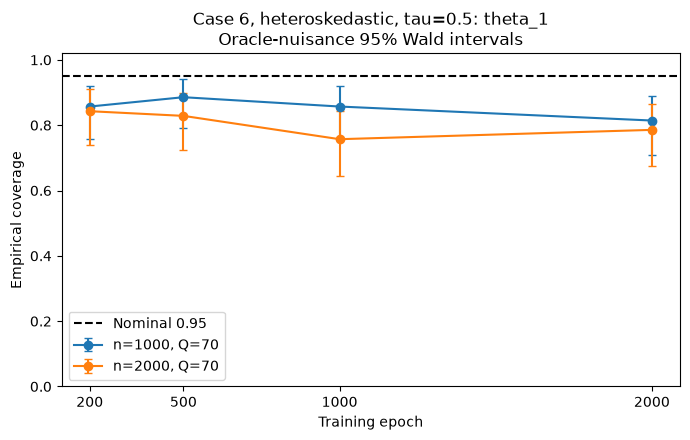

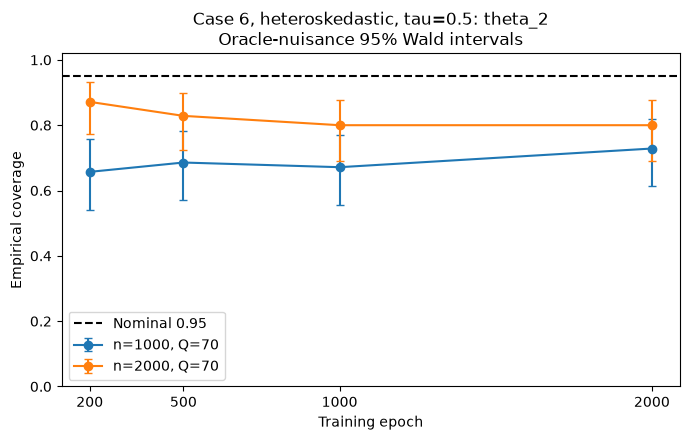

New files created by this execution:
results\2026-09-15_heteroskedastic_epoch_drift_case6\run_x1_x2\coverage_diagnostics\20260916T045222_904106Z_e7fe40dd\coverage_config.json
results\2026-09-15_heteroskedastic_epoch_drift_case6\run_x1_x2\coverage_diagnostics\20260916T045222_904106Z_e7fe40dd\coverage_plot_summary_complete_trajectories.csv
results\2026-09-15_heteroskedastic_epoch_drift_case6\run_x1_x2\coverage_diagnostics\20260916T045222_904106Z_e7fe40dd\coverage_replications.csv
results\2026-09-15_heteroskedastic_epoch_drift_case6\run_x1_x2\coverage_diagnostics\20260916T045222_904106Z_e7fe40dd\coverage_summary.csv
results\2026-09-15_heteroskedastic_epoch_drift_case6\run_x1_x2\coverage_diagnostics\20260916T045222_904106Z_e7fe40dd\coverage_table_theta1.csv
results\2026-09-15_heteroskedastic_epoch_drift_case6\run_x1_x2\coverage_diagnostics\20260916T045222_904106Z_e7fe40dd\coverage_table_theta2.csv
results\2026-09-15_heteroskedastic_epoch_drift_case6\run_x1_x2\coverage_diagnostics\20260916T

In [6]:
paired_intervals = intervals.merge(complete_keys, on=["n_total", "replication"],
                                  how="inner", validate="many_to_one")
if paired_intervals.empty:
    print("No complete trajectories yet; coverage summary above still uses all saved checkpoint rows.")
else:
    plot_summary = coverage_summary(paired_intervals)
    save_csv(plot_summary, "coverage_plot_summary_complete_trajectories.csv")
    for j in (1, 2):
        fig, ax = plt.subplots(figsize=(7, 4.5))
        for n in N_LIST:
            values = plot_summary[(plot_summary.n_total == n) &
                (plot_summary.component == f"theta_{j}")].sort_values("epoch")
            if values.empty:
                continue
            errors = np.maximum(0, np.vstack([
                values.coverage-values.coverage_wilson_lower,
                values.coverage_wilson_upper-values.coverage]))
            q = int(values.Q_available.iloc[0])
            ax.errorbar(values.epoch, values.coverage, yerr=errors, marker="o", capsize=3,
                        label=f"n={n}, Q={q}")
        ax.axhline(CONFIDENCE_LEVEL, color="black", linestyle="--", label="Nominal 0.95")
        ax.set(xticks=EPOCHS, xlabel="Training epoch", ylabel="Empirical coverage",
               ylim=(0, 1.02), title=f"Case 6, heteroskedastic, tau=0.5: theta_{j}\nOracle-nuisance 95% Wald intervals")
        ax.legend(fontsize=10)
        ax.tick_params(labelsize=10)
        fig.tight_layout()
        fig.savefig(COVERAGE_DIR / f"coverage_theta{j}_versus_epoch.png", dpi=160, bbox_inches="tight")
        plt.show()
        plt.close(fig)

# Confirm the source CSV has not changed during this read-only post-processing session.
if hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() != analysis_config["raw_sha256"]:
    raise RuntimeError("The input CSV changed during analysis; rerun against a stable saved run.")
print("New files created by this execution:")
for output in sorted(COVERAGE_DIR.iterdir()):
    if output.is_file():
        print(output.relative_to(ROOT))


## Interpretation

- Coverage near 0.95 means these oracle-nuisance intervals contain the true coefficient at about
  their nominal frequency across the saved replications. Account for Monte Carlo uncertainty.
- Undercoverage can reflect bias, an incorrect finite-sample variance scale, or non-Gaussian tails.
  Compare bias, MC SD, mean oracle SE, and the mean/SD of the studentized statistic to distinguish them.
- Poor coverage even with oracle nuisances cannot be explained solely by estimating those nuisances.
  Good oracle coverage does not establish that a practical estimated-nuisance method will work equally well.
- Epoch comparisons assess this finite-sample optimization trajectory. They neither prove nor disprove
  asymptotic consistency or a theorem. The fixed architecture, absence of early stopping, corrected
  x1+x2 DGP, and oracle interval method differ from the paper's Table 2 experiment.